# CFN accuracy experiments (Colab)
Notes and runnable cells to iterate on the Causal Fusion Network (CFN), test detection accuracy, and try improvements safely.

## Embedding-aware CFN (TCN + Wav2Vec2)
- Ensure your CSV includes `tcn_visual_emb` and `wav2vec_audio_emb`.
- Train with `--use-embeddings` to produce `models/cfn_emb.pth`.
- Enable inference with: `CFN_USE_EMBEDDINGS=true` and `CFN_EMB_MODEL_PATH=models/cfn_emb.pth`.
- Optional SCM score: set `CFN_ENABLE_SCM_CHECKS=true`.


## Embedding pipeline (wav2vec2 + VisualTCN)
End-to-end steps to cache checkpoints, build an embedding CSV, train CFN with embeddings, and run inference/eval.


Setup/Import cell

In [1]:
# Cache wav2vec2 checkpoint (one-time)
import pathlib, os, subprocess, sys
ckpt_dir = pathlib.Path('~/.cache/torch/hub/checkpoints').expanduser()
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt = ckpt_dir/'wav2vec2_fairseq_base_ls960.pth'
if not ckpt.exists():
    !wget -O "{ckpt}" https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960.pth
print('wav2vec2 cached:', ckpt.exists(), ckpt)


wav2vec2 cached: True /Users/venturit/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960.pth


Build the embedding CSV

In [2]:
# Runtime env for embeddings + CPU-only mediapipe (local + Colab)
import os
import sys
from pathlib import Path

_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend'),
    Path('/content/CausalX-Project/backend'),
]
PROJECT_ROOT = next((c for c in _candidates if (c / 'src').exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate backend root with src/ directory.')

DATA_ROOT = PROJECT_ROOT / 'data'
RAW_ROOT = DATA_ROOT / 'raw' / 'fakeavceleb'
sys.path.insert(0, str(PROJECT_ROOT))

os.environ['CFN_USE_EMBEDDINGS'] = 'true'
os.environ['CFN_W2V2_MODEL'] = 'WAV2VEC2_BASE'
os.environ['MEDIAPIPE_DISABLE_GPU'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RAW_ROOT exists:', RAW_ROOT.exists())


PROJECT_ROOT: /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend
RAW_ROOT exists: True


In [9]:
from pathlib import Path
import sys, os, random
import numpy as np
import pandas as pd
import librosa

if 'PROJECT_ROOT' not in globals() or not (Path(PROJECT_ROOT) / 'src').exists():
    _candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path('/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend'),
        Path('/content/CausalX-Project/backend'),
    ]
    PROJECT_ROOT = next((c for c in _candidates if (c / 'src').exists()), None)
    if PROJECT_ROOT is None:
        raise RuntimeError('Could not locate backend root with src/ directory.')
else:
    PROJECT_ROOT = Path(PROJECT_ROOT)

DATA_ROOT = PROJECT_ROOT / 'data'
RAW_ROOT = DATA_ROOT / 'raw' / 'fakeavceleb'
sys.path.insert(0, str(PROJECT_ROOT))

os.environ['CFN_USE_EMBEDDINGS'] = 'true'
os.environ['CFN_W2V2_MODEL'] = 'WAV2VEC2_BASE'
os.environ['MEDIAPIPE_DISABLE_GPU'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

from src.utils.dataset_registry import get_fakeavceleb_videos
from src.cvi.feature_extractor import FeatureExtractor
from src.cvi.frame_causal_extractor import extract_frame_level_features

fe = FeatureExtractor()
videos = get_fakeavceleb_videos(RAW_ROOT)
random.shuffle(videos)

rows = []
for v in videos[:400]:
    frames = extract_frame_level_features(v['path'], duration=8.0)
    if not frames:
        continue
    lip = np.array([f['lip_aperture'] for f in frames], np.float32)
    audio_rms = np.array([f['audio_rms'] for f in frames], np.float32)
    wav, sr = librosa.load(v['path'], sr=16000, duration=8.0)
    vis = fe.get_visual_embeddings(lip)
    wav_emb = fe.get_audio_embeddings(wav, sr=sr)
    rows.append({
        'path': v['path'],
        'label': v['label'],
        'lip_variance': float(lip.var()),
        'av_correlation': float(np.corrcoef(lip, audio_rms)[0, 1]) if len(lip) > 1 else 0.0,
        'av_lag_frames': 0.0,
        'jitter_mean': float(np.mean([f.get('jitter', 0.0) for f in frames])),
        'jitter_std': float(np.std([f.get('jitter', 0.0) for f in frames])),
        'tcn_visual_emb': float(np.mean(vis)) if vis.size else 0.0,
        'wav2vec_audio_emb': float(np.mean(wav_emb)) if wav_emb.size else 0.0,
    })

out = DATA_ROOT / 'processed' / 'causal_multimodal_embeddings.csv'
out.parent.mkdir(parents=True, exist_ok=True)
pd.DataFrame(rows).to_csv(out, index=False)
print('wrote', len(rows), 'rows to', out)


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/var/folders/wz/x36xnpv15rj4ghbz7z48t88m0000gn/T/ipykernel_88278/922718815.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  wa

wrote 400 rows to /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/data/processed/causal_multimodal_embeddings.csv


Train CFN with embeddings

In [4]:
# Train CFN with embeddings (local/colab safe)
import subprocess
import sys
from pathlib import Path

if 'PROJECT_ROOT' not in globals() or not (Path(PROJECT_ROOT) / 'src').exists():
    _candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path('/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend'),
        Path('/content/CausalX-Project/backend'),
    ]
    PROJECT_ROOT = next((c for c in _candidates if (c / 'src').exists()), None)
    if PROJECT_ROOT is None:
        raise RuntimeError('Could not locate backend root with src/ directory.')
else:
    PROJECT_ROOT = Path(PROJECT_ROOT)

py = PROJECT_ROOT / '.venv' / 'bin' / 'python'
python_exe = str(py) if py.exists() else sys.executable
data_csv = PROJECT_ROOT / 'data' / 'processed' / 'causal_multimodal_embeddings.csv'
if not data_csv.exists():
    raise FileNotFoundError(f'Missing CSV: {data_csv}. Run embedding CSV cell first.')

cmd = [
    python_exe, '-m', 'src.training.train_cfn',
    '--data', 'data/processed/causal_multimodal_embeddings.csv',
    '--use-scaler', '--use-embeddings',
    '--epochs', '15', '--patience', '4', '--batch-size', '128',
]
print('Running:', ' '.join(cmd))
subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)


Running: /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/bin/python -m src.training.train_cfn --data data/processed/causal_multimodal_embeddings.csv --use-scaler --use-embeddings --epochs 15 --patience 4 --batch-size 128
Using seed: 42
Loaded 400 rows from data/processed/causal_multimodal_embeddings.csv; using 400 rows after --train-source=fakeavceleb filter.
Label prevalence: pos=0.9800, neg=0.0200
Using dataset+label stratified split across 2 groups.
Weight application (auto) resolved to: loss.
Epoch 01 | train_loss=0.6931 val_loss=0.6104 val_acc=0.975 val_auc=0.577 pr_auc=0.985 best_f1=0.987 best_thr=0.529 sel_thr=0.500 sel_prec=0.975 sel_rec=1.000 sel_f1=0.987 worst_bal=0.500 worst_spec=0.000 worst_rec=1.000 sel_score=0.500
Epoch 02 | train_loss=0.6910 val_loss=0.6141 val_acc=0.975 val_auc=0.564 pr_auc=0.985 best_f1=0.987 best_thr=0.528 sel_thr=0.500 sel_prec=0.975 sel_rec=1.000 sel_f1=0.987 worst_bal=0.500 worst_spec=0.000 worst_rec=1.000 sel_score=0.500
Epoch 0

CompletedProcess(args=['/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/bin/python', '-m', 'src.training.train_cfn', '--data', 'data/processed/causal_multimodal_embeddings.csv', '--use-scaler', '--use-embeddings', '--epochs', '15', '--patience', '4', '--batch-size', '128'], returncode=0)

 Train VisualTCN

In [5]:
from src.modules.embeddings import VisualTCN
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from pathlib import Path

if 'videos' not in globals():
    raise RuntimeError("`videos` is not defined. Run the embedding data-prep cell first.")

if 'extract_frame_level_features' not in globals():
    from src.cvi.frame_causal_extractor import extract_frame_level_features

project_root = Path(globals().get('PROJECT_ROOT', Path.cwd()))
if not (project_root / 'src').exists() and (project_root / 'backend' / 'src').exists():
    project_root = project_root / 'backend'

models_dir = project_root / 'models' if (project_root / 'src').exists() else Path('backend/models')
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / 'visual_tcn.pth'

seqs, labels = [], []
for v in videos[:200]:
    frames = extract_frame_level_features(v['path'], duration=6.0)
    if len(frames) < 20:
        continue
    lip = np.array([f['lip_aperture'] for f in frames], np.float32)
    lip = (lip - lip.mean()) / (lip.std() + 1e-6)
    seqs.append(lip[:256])
    labels.append(v['label'])

if not seqs:
    raise RuntimeError('No usable frame sequences were extracted for VisualTCN training.')

max_len = max(len(s) for s in seqs)
seqs = [np.pad(s, (0, max_len - len(s))) for s in seqs]
X = torch.tensor(seqs, dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.float32)

model = VisualTCN(out_dim=64)
clf = nn.Linear(64, 1)
opt = optim.Adam(list(model.parameters()) + list(clf.parameters()), lr=1e-3)
bce = nn.BCEWithLogitsLoss()

for epoch in range(8):
    opt.zero_grad()
    z = model(X)
    loss = bce(clf(z).squeeze(1), y)
    loss.backward()
    opt.step()
    print('epoch', epoch + 1, 'loss', float(loss))

torch.save(model.state_dict(), model_path)
print(f'saved visual TCN to {model_path}')


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	

epoch 1 loss 0.6894256472587585
epoch 2 loss 0.6713244915008545
epoch 3 loss 0.652942955493927
epoch 4 loss 0.6339058876037598
epoch 5 loss 0.6136255860328674
epoch 6 loss 0.5916193127632141
epoch 7 loss 0.5675092935562134
epoch 8 loss 0.5411256551742554
saved visual TCN to /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/models/visual_tcn.pth


In [6]:
import os

# Raise prob threshold to reduce false positives; raise ratio to require more flagged frames.
os.environ["CFN_PROB_THRESH"] = "0.7"
os.environ["CFN_RATIO_THRESH"] = "0.4"

print("Using CFN_PROB_THRESH", os.environ["CFN_PROB_THRESH"],
      "CFN_RATIO_THRESH", os.environ["CFN_RATIO_THRESH"])


Using CFN_PROB_THRESH 0.7 CFN_RATIO_THRESH 0.4


Inference demo

In [7]:
from pathlib import Path
from src.cvi.api.inference_service import run_full_cvi_pipeline
from src.utils.dataset_registry import get_fakeavceleb_videos

if 'PROJECT_ROOT' not in globals() or not (Path(PROJECT_ROOT) / 'src').exists():
    raise RuntimeError('Run setup cell first to define PROJECT_ROOT and RAW_ROOT.')

videos = get_fakeavceleb_videos(RAW_ROOT)
if not videos:
    raise RuntimeError(f'No videos found under {RAW_ROOT}')

sample = next((v for v in videos if int(v.get('label', 0)) == 1), videos[0])
video_path = Path(sample['path'])

out = run_full_cvi_pipeline(str(video_path))
print('video_path:', video_path)
print('video_fake:', out['video_fake'], 'confidence:', out['fake_confidence'])
print('highlight_timestamps:', out['highlight_timestamps'][:10])


I0000 00:00:1772908966.204458       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


video_path: /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/data/raw/fakeavceleb/FakeVideo-FakeAudio/African/men/id01856/00006_id01076_wavtolip.mp4
video_fake: 1 confidence: 0.7733333333333333
highlight_timestamps: [0.84, 0.88, 1.96, 2.0, 2.04, 0.08, 0.12, 0.16, 0.2, 0.24]


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/cfn_frame_inference.py:168: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(video_path, sr=16000, offset=offset, duration=duration)


In [8]:
from pathlib import Path
import random
import csv
from src.cvi.api.inference_service import run_full_cvi_pipeline
from src.utils.dataset_registry import get_fakeavceleb_videos

if 'PROJECT_ROOT' not in globals() or not (Path(PROJECT_ROOT) / 'src').exists():
    raise RuntimeError('Run setup cell first to define PROJECT_ROOT and RAW_ROOT.')

manifest = PROJECT_ROOT / 'eval_manifest_balanced.tsv'
if not manifest.exists():
    videos = get_fakeavceleb_videos(RAW_ROOT)
    fakes = [v for v in videos if int(v['label']) == 1]
    reals = [v for v in videos if int(v['label']) == 0]
    n = min(len(fakes), len(reals), 100)
    random.shuffle(fakes)
    random.shuffle(reals)
    sample = fakes[:n] + reals[:n]
    random.shuffle(sample)
    with manifest.open('w', newline='') as f:
        w = csv.writer(f, delimiter='	')
        for v in sample:
            w.writerow([v['path'], v['label']])
    print('Created manifest:', manifest, 'rows=', len(sample))


tp = tn = fp = fn = skipped = 0
with manifest.open() as f:
    for line in f:
        path_str, label = line.strip().split('	')
        p = Path(path_str)
        if not p.is_absolute():
            p = PROJECT_ROOT / p

        try:
            r = run_full_cvi_pipeline(str(p))
        except Exception as e:
            skipped += 1
            print(f'Skipping {p} ({e})')
            continue

        pred = r['video_fake']
        label = int(label)
        if pred == 1 and label == 1:
            tp += 1
        elif pred == 0 and label == 0:
            tn += 1
        elif pred == 1 and label == 0:
            fp += 1
        else:
            fn += 1

total = tp + tn + fp + fn
acc = (tp + tn) / total if total else 0
prec = tp / (tp + fp) if (tp + fp) else 0
rec = tp / (tp + fn) if (tp + fn) else 0
f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
print(f'Acc={acc:.3f} Prec={prec:.3f} Rec={rec:.3f} F1={f1:.3f} TP={tp} TN={tn} FP={fp} FN={fn} Skipped={skipped}')


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/cfn_frame_inference.py:168: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(video_path, sr=16000, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=of

Acc=0.515 Prec=0.508 Rec=0.990 F1=0.671 TP=99 TN=4 FP=96 FN=1 Skipped=0


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/cfn_frame_inference.py:168: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(video_path, sr=16000, offset=offset, duration=duration)


## New training workflow helpers
- Use `backend/scripts/run_training_pipeline.sh` to run feature extraction, optional balancing, and CFN training in one pass.
- Use `backend/scripts/run_embedding_training.sh` to train the embedding-aware CFN model.
- Copy `backend/.env.example` to `.env` and set `CFN_PROB_THRESH` / `CFN_RATIO_THRESH` only as a short-term tuning lever (prefer retraining).


## 0) Runtime
- Runtime type: GPU (T4/A100 preferred)
- Python: 3.9+
- Enable persistent session if running sweeps

In [9]:
# Optional: mount Drive if your datasets/models live there (Colab only)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted at /content/drive')
except ModuleNotFoundError:
    print('google.colab not available; skipping Drive mount (non-Colab runtime).')


google.colab not available; skipping Drive mount (non-Colab runtime).


## 2) Smoke test on one video

In [10]:
from pathlib import Path
from src.cvi.cfn_frame_inference import run_cfn_on_video
from src.cvi.api.inference_service import summarize_video
from src.utils.dataset_registry import get_fakeavceleb_videos

if 'PROJECT_ROOT' not in globals() or not (Path(PROJECT_ROOT) / 'src').exists():
    raise RuntimeError('Run setup cell first to define PROJECT_ROOT and RAW_ROOT.')

videos = get_fakeavceleb_videos(RAW_ROOT)
if not videos:
    raise RuntimeError(f'No videos found under {RAW_ROOT}')

video = videos[0]['path']

frames = run_cfn_on_video(
    video,
    threshold=0.6,
    chunk_seconds=10,
    max_seconds=None,
)

video_fake, fake_conf, highlight = summarize_video(
    frames,
    prob_thresh=0.6,
    ratio_thresh=0.3,
)
print(f'video={video}')
print(f'frames={len(frames)}, video_fake={video_fake}, conf={fake_conf:.3f}')


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


video=/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/data/raw/fakeavceleb/RealVideo-RealAudio/African/men/id01856/00006.mp4
frames=99, video_fake=1, conf=0.616


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/cfn_frame_inference.py:168: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(video_path, sr=16000, offset=offset, duration=duration)


## 3) Batch evaluation helper

In [11]:
import glob
from pathlib import Path
from tqdm import tqdm
from src.cvi.api.inference_service import summarize_video
from src.cvi.cfn_frame_inference import run_cfn_on_video

def evaluate_dir(video_dir, prob_thresh=0.6, ratio_thresh=0.3, max_files=30):
    rows = []
    video_dir = Path(video_dir)
    files = sorted(glob.glob(str(video_dir / '**' / '*.mp4'), recursive=True))
    if max_files is not None:
        files = files[:max_files]
    for path in tqdm(files):
        frames = run_cfn_on_video(path, threshold=prob_thresh, chunk_seconds=10)
        label, conf, _ = summarize_video(frames, prob_thresh=prob_thresh, ratio_thresh=ratio_thresh)
        rows.append({'video': path, 'video_fake': label, 'fake_conf': conf})
    return rows

if 'RAW_ROOT' not in globals():
    raise RuntimeError('Run setup cell first to define RAW_ROOT.')

rows = evaluate_dir(RAW_ROOT, max_files=20)
rows[:3]


  0%|          | 0/20 [00:00<?, ?it/s]/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/cfn_frame_inference.py:168: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(video_path, sr=16000, offset=offset, duration=duration)
  5%|▌         | 1/20 [00:00<00:11,  1.71it/s]/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundF

[{'video': '/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/data/raw/fakeavceleb/FakeVideo-FakeAudio/African/men/id00076/00109_10_id00476_wavtolip.mp4',
  'video_fake': 1,
  'fake_conf': 0.7641509433962265},
 {'video': '/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/data/raw/fakeavceleb/FakeVideo-FakeAudio/African/men/id00076/00109_10_id01076_wavtolip.mp4',
  'video_fake': 1,
  'fake_conf': 0.6666666666666666},
 {'video': '/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/data/raw/fakeavceleb/FakeVideo-FakeAudio/African/men/id00076/00109_10_id01179_wavtolip.mp4',
  'video_fake': 1,
  'fake_conf': 0.8018867924528302}]

## 4) Techniques to test
Each section below has a short description and a runnable cell.

### 4.1 Threshold sweep (prob_thresh, ratio_thresh)
Grid-search operating points; compute simple metrics.

In [12]:
import itertools
import pandas as pd
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support

# Assumes rows_gt with ground-truth labels, e.g. [{"video":..., "gt":0/1}]
prob_grid = [0.4, 0.5, 0.6, 0.7]
ratio_grid = [0.2, 0.3, 0.4]

if 'RAW_ROOT' not in globals():
    raise RuntimeError('Run setup cell first to define RAW_ROOT.')

EVAL_VIDEO_DIR = Path(RAW_ROOT)

def sweep_thresholds(rows_gt, prob_grid, ratio_grid, video_dir=EVAL_VIDEO_DIR):
    records = []
    for p, r in itertools.product(prob_grid, ratio_grid):
        preds = evaluate_dir(video_dir, prob_thresh=p, ratio_thresh=r, max_files=30)
        merged = pd.DataFrame(rows_gt).merge(pd.DataFrame(preds), on='video')
        prec, rec, f1, _ = precision_recall_fscore_support(
            merged['gt'], merged['video_fake'], average='binary', zero_division=0
        )
        records.append({'prob_thresh': p, 'ratio_thresh': r, 'precision': prec, 'recall': rec, 'f1': f1})
    return pd.DataFrame(records)

# rows_gt = [...]  # build from the same set of videos you evaluate
# sweep_df = sweep_thresholds(rows_gt, prob_grid, ratio_grid)
# sweep_df.sort_values('f1', ascending=False).head()


### 4.2 Temporal smoothing
Apply a moving average over frame-level `fake_prob` to reduce spikes before summarizing.

In [13]:
import numpy as np
from scipy.ndimage import uniform_filter1d
from src.cvi.api.inference_service import summarize_video

def summarize_with_smoothing(frames, prob_thresh=0.6, ratio_thresh=0.3, window=5):
    probs = np.array([f["fake_prob"] for f in frames])
    smooth = uniform_filter1d(probs, size=window, mode="nearest")
    for f, s in zip(frames, smooth):
        f["fake_prob_smooth"] = float(s)
    return summarize_video(frames, prob_thresh=prob_thresh, ratio_thresh=ratio_thresh)

# Example: video_fake, fake_conf, highlight = summarize_with_smoothing(frames, window=7)

### 4.3 Chunk sizing
Compare `chunk_seconds` (e.g., 5/10/15) for latency vs. stability.

In [14]:
import time

def benchmark_chunks(video_path, chunk_sizes=(5, 10, 15)):
    results = []
    for cs in chunk_sizes:
        start = time.time()
        frames = run_cfn_on_video(video_path, threshold=0.6, chunk_seconds=cs)
        elapsed = time.time() - start
        results.append({"chunk_seconds": cs, "frames": len(frames), "seconds": elapsed})
    return results

# benchmark_chunks(video)

### 4.4 Audio/video lag search
Evaluate small AV shifts to reduce desync noise.

In [15]:
import numpy as np

def av_lag_scores(frames, lags_ms=(-120, -60, 0, 60, 120)):
    scores = []
    base_lips = np.array([f["lip_aperture"] for f in frames])
    for lag in lags_ms:
        shifted_audio = np.array([f["audio_rms"] for f in frames])
        # crude shift by rolling; for precise shift re-run feature extraction with offset
        shift_frames = int(lag / 1000 * 30)  # assumes ~30 fps
        shifted_audio = np.roll(shifted_audio, shift_frames)
        corr = np.corrcoef(base_lips, shifted_audio)[0, 1]
        scores.append({"lag_ms": lag, "corr": float(corr)})
    return scores

# av_lag_scores(frames)

### 4.5 Feature weighting / model variants
Hook to rescale features before CFN to prototype weighting; useful if you add more cues.

In [16]:
def run_with_feature_scale(video_path, av_scale=1.0, phys_scale=1.0):
    frames = run_cfn_on_video(video_path, threshold=0.6)
    for f in frames:
        f["av_mismatch"] *= av_scale
        f["jitter"] = f.get("jitter", 0.0) * phys_scale
    return frames

# frames_scaled = run_with_feature_scale(video, av_scale=1.2, phys_scale=0.8)

### 4.6 Augmentations for fine-tuning
Example: mild audio speed perturbation and landmark jitter to stress-test robustness (use for training, not inference).

In [17]:
import librosa
import numpy as np

def augment_audio_speed(y, rate=1.02):
    return librosa.effects.time_stretch(y, rate=rate)

def jitter_landmarks(pts, sigma=0.002):
    noise = np.random.normal(scale=sigma, size=pts.shape)
    return pts + noise

# Use these in your data loader when re-training CFN

### 4.7 Bounding-box gating
Visual check: bboxes only where `fake_prob >= threshold`.

In [18]:
import cv2

def draw_bboxes(video_path, frames, out_path="annotated.mp4"):
    cap = cv2.VideoCapture(video_path)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = cv2.VideoWriter(out_path, fourcc, fps, (w, h))

    frame_map = {int(f["timestamp"] * fps): f for f in frames}

    idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        info = frame_map.get(idx)
        if info and info.get("bbox"):
            x1, y1, x2, y2 = info["bbox"]
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
        writer.write(frame)
        idx += 1

    cap.release()
    writer.release()

# draw_bboxes(video, frames, out_path="annotated.mp4")

## 5) Logging results
- Keep a CSV of experiment configs and metrics (thresholds, chunk size, smoothing window).
- Save short snippets of failure cases for qualitative review.

## Balanced eval + threshold sweep (updated)
Creates a balanced manifest, lets you tune thresholds via env vars, and reports specificity/balanced accuracy.


In [19]:
from pathlib import Path
import sys, os, random, numpy as np, pandas as pd, librosa

_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend'),
    Path('/content/CausalX-Project/backend'),
]
PROJECT_ROOT = next((c for c in _candidates if (c / 'src').exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate backend root with src/ directory.')

DATA_ROOT = PROJECT_ROOT / 'data'
RAW_ROOT = DATA_ROOT / 'raw' / 'fakeavceleb'

sys.path.insert(0, str(PROJECT_ROOT))
os.environ['CFN_USE_EMBEDDINGS'] = 'true'
os.environ['CFN_W2V2_MODEL'] = 'WAV2VEC2_BASE'
os.environ['MEDIAPIPE_DISABLE_GPU'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RAW_ROOT exists:', RAW_ROOT.exists())


PROJECT_ROOT: /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend
RAW_ROOT exists: True


In [20]:
import os
os.environ['CFN_PROB_THRESH'] = '0.7'
os.environ['CFN_RATIO_THRESH'] = '0.4'
print('CFN_PROB_THRESH', os.environ['CFN_PROB_THRESH'], 'CFN_RATIO_THRESH', os.environ['CFN_RATIO_THRESH'])


CFN_PROB_THRESH 0.7 CFN_RATIO_THRESH 0.4


In [21]:
from src.utils.dataset_registry import get_fakeavceleb_videos
import csv
videos = get_fakeavceleb_videos(RAW_ROOT)
fakes = [v for v in videos if v['label']==1]
reals = [v for v in videos if v['label']==0]
n = min(len(fakes), len(reals), 200)
random.shuffle(fakes); random.shuffle(reals)
sample = fakes[:n] + reals[:n]
random.shuffle(sample)
manifest = PROJECT_ROOT/'eval_manifest_balanced.tsv'
with manifest.open('w') as f:
    w = csv.writer(f, delimiter='	')
    for v in sample:
        w.writerow([v['path'], v['label']])
print('Wrote', len(sample), 'rows to', manifest)


Wrote 400 rows to /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/eval_manifest_balanced.tsv


In [22]:
from src.cvi.api.inference_service import run_full_cvi_pipeline
from pathlib import Path
tp=tn=fp=fn=skipped=0
manifest = PROJECT_ROOT/'eval_manifest_balanced.tsv'
for line in manifest.read_text().splitlines():
    path_str, label = line.split('	')
    p = Path(path_str)
    if not p.is_absolute():
        p = PROJECT_ROOT / p
    try:
        r = run_full_cvi_pipeline(str(p))
    except Exception as e:
        skipped += 1
        print('Skip', p, e)
        continue
    pred = r['video_fake']; label=int(label)
    if pred==1 and label==1: tp+=1
    elif pred==0 and label==0: tn+=1
    elif pred==1 and label==0: fp+=1
    else: fn+=1
total = tp+tn+fp+fn
acc = (tp+tn)/total if total else 0
prec = tp/(tp+fp) if (tp+fp) else 0
rec = tp/(tp+fn) if (tp+fn) else 0
spec = tn/(tn+fp) if (tn+fp) else 0
bal_acc = 0.5*(rec+spec)
f1 = 2*prec*rec/(prec+rec) if (prec+rec) else 0
print(f'Acc={acc:.3f} Prec={prec:.3f} Rec={rec:.3f} Spec={spec:.3f} BalAcc={bal_acc:.3f} F1={f1:.3f} TP={tp} TN={tn} FP={fp} FN={fn} Skipped={skipped}')


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/cfn_frame_inference.py:168: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(video_path, sr=16000, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=of

Acc=0.532 Prec=0.517 Rec=1.000 Spec=0.065 BalAcc=0.532 F1=0.681 TP=200 TN=13 FP=187 FN=0 Skipped=0


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/User

In [23]:
from src.cvi.api.inference_service import run_full_cvi_pipeline
video_path = PROJECT_ROOT / 'data/raw/fakeavceleb/FakeVideo-FakeAudio/African/men/id00076/00109_2_id00166_wavtolip.mp4'
r = run_full_cvi_pipeline(str(video_path))
print('video_fake', r['video_fake'], 'confidence', r['fake_confidence'])
print('highlights', r['highlight_timestamps'][:10])


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/frame_causal_extractor.py:82: UserWarning: PySoundFile failed. Trying audioread instead.
  return librosa.load(path, sr=None, offset=offset, duration=duration)
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


video_fake 1 confidence 0.6764705882352942
highlights [0.08, 0.12, 0.28, 0.32, 0.36, 0.4, 0.64, 0.68, 1.76, 1.8]


/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/src/cvi/cfn_frame_inference.py:168: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(video_path, sr=16000, offset=offset, duration=duration)


## 6) Classification-metric improvement sweeps (trainer-level)
Use this section to optimize training for classification targets directly from notebook.
- Uses the updated `src.training.train_cfn` options (`--selection-threshold-mode target`, `--target-*`, `--weight-application`, leakage-safe split).
- Compares multiple train configs quickly and logs a leaderboard.
- Saves per-run threshold report (`cfn_threshold_report.json`) for auditability.


In [11]:
from pathlib import Path
import os, sys, json, shlex, subprocess
import pandas as pd

# Resolve backend root (works for local + Colab)
if 'PROJECT_ROOT' in globals() and (Path(PROJECT_ROOT) / 'src').exists():
    BACKEND_ROOT = Path(PROJECT_ROOT)
else:
    _candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path('/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend'),
        Path('/content/CausalX-Project/backend'),
    ]
    BACKEND_ROOT = next((c for c in _candidates if (c / 'src').exists()), None)

if BACKEND_ROOT is None:
    raise RuntimeError('Cannot find backend root with src/ directory.')

sys.path.insert(0, str(BACKEND_ROOT))

PYTHON_BIN = BACKEND_ROOT / '.venv/bin/python'
PYTHON_EXE = str(PYTHON_BIN) if PYTHON_BIN.exists() else sys.executable

print('BACKEND_ROOT =', BACKEND_ROOT)
print('PYTHON_EXE  =', PYTHON_EXE)

BASE_ARGS = [
    '-m', 'src.training.train_cfn',
    '--data', 'data/processed/causal_multimodal_dataset_mixed_train.csv',
    '--train-source', 'all',
    '--group-split-col', 'video_id',
    '--use-embeddings', '--use-scaler',
    '--group-balance',
    '--scheduler', 'cosine',
    '--batch-size', '128',
    '--lr', '2e-4',
    '--weight-decay', '1e-4',
    '--seed', '42',
    '--selection-metric', 'hybrid_robust',
    '--selection-threshold-mode', 'target',
    '--target-acc', '0.90',
    '--target-precision', '0.95',
    '--target-recall', '0.88',
    '--target-f1', '0.90',
    '--target-priority', 'f1',
    '--min-domain-spec', '0.05',
    '--min-domain-rec', '0.20',
]

def run_train_experiment(name: str, extra_args: str = '', epochs: int = 20, patience: int = 6):
    out_dir = BACKEND_ROOT / 'models' / f'nb_cls_{name}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [PYTHON_EXE] + BASE_ARGS + [
        '--epochs', str(epochs),
        '--patience', str(patience),
        '--model-dir', str(out_dir),
    ] + shlex.split(extra_args)

    print('\n' + '=' * 100)
    print('EXPERIMENT:', name)
    print('CMD:', ' '.join(shlex.quote(x) for x in cmd))
    subprocess.run(cmd, cwd=BACKEND_ROOT, check=True)

    rep_path = out_dir / 'cfn_threshold_report.json'
    if not rep_path.exists():
        raise FileNotFoundError(f'Missing report: {rep_path}')
    rep = json.loads(rep_path.read_text())
    chosen = rep['chosen_epoch_report']
    overall = chosen['overall_at_selection_threshold']

    return {
        'name': name,
        'epochs': epochs,
        'selection_mode': rep.get('selection_threshold_mode'),
        'checkpoint_meets_constraints': rep.get('best_checkpoint_met_constraints'),
        'best_epoch': chosen.get('epoch'),
        'auc': chosen.get('val_auc'),
        'pr_auc': chosen.get('pr_auc'),
        'sel_score': chosen.get('selection_score'),
        'thr': chosen.get('selection_threshold'),
        'acc': overall.get('acc'),
        'prec': overall.get('prec'),
        'rec': overall.get('rec'),
        'f1': overall.get('f1'),
        'spec': overall.get('spec'),
        'bal_acc': overall.get('bal_acc'),
        'targets_met': chosen.get('targets_met'),
        'target_gap': chosen.get('target_shortfall'),
        'model_dir': str(out_dir),
        'report_path': str(rep_path),
    }


BACKEND_ROOT = /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend
PYTHON_EXE  = /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/bin/python


In [12]:
import pandas as pd
# Suggested sweep: start with BCE/no causal, then compare weighting + balancing modes.
# Strict promotion gates (tune these for your target quality bar).
MIN_SPEC_FOR_PROMOTION = 0.40
MIN_BAL_ACC_FOR_PROMOTION = 0.65
MIN_AUC_FOR_PROMOTION = 0.60
REQUIRE_TARGETS_MET_FOR_PROMOTION = True

EXPERIMENTS = [
    ('bce_auto', '--loss bce --causal-weight 0.0 --use-weighted-sampler --weight-application auto'),
    ('bce_loss', '--loss bce --causal-weight 0.0 --weight-application loss'),
    ('bce_sampler', '--loss bce --causal-weight 0.0 --use-weighted-sampler --weight-application sampler'),
    ('bce_both', '--loss bce --causal-weight 0.0 --use-weighted-sampler --weight-application both'),
    ('focal_auto', '--loss focal --focal-alpha 0.70 --focal-gamma 1.5 --causal-weight 0.0 --use-weighted-sampler --weight-application auto'),
    ('downsample_bce', '--class-balance-mode downsample --loss bce --causal-weight 0.0 --weight-application loss'),
    ('upsample_bce', '--class-balance-mode upsample --loss bce --causal-weight 0.0 --weight-application loss'),
]

rows = []
for name, extra in EXPERIMENTS:
    try:
        rows.append(run_train_experiment(name, extra_args=extra, epochs=20, patience=6))
    except Exception as e:
        rows.append({'name': name, 'error': str(e)})

leaderboard = pd.DataFrame(rows)
if 'error' in leaderboard.columns:
    display(leaderboard[['name', 'error']].dropna(how='all'))

# Ensure required metric columns exist.
for c in ['spec', 'bal_acc', 'auc', 'targets_met', 'target_gap', 'sel_score', 'f1']:
    if c not in leaderboard.columns:
        leaderboard[c] = pd.NA

if REQUIRE_TARGETS_MET_FOR_PROMOTION:
    targets_mask = leaderboard['targets_met'].fillna(False)
else:
    targets_mask = pd.Series([True] * len(leaderboard), index=leaderboard.index)

leaderboard['strict_pass'] = (
    leaderboard['spec'].fillna(-1).astype(float).ge(MIN_SPEC_FOR_PROMOTION)
    & leaderboard['bal_acc'].fillna(-1).astype(float).ge(MIN_BAL_ACC_FOR_PROMOTION)
    & leaderboard['auc'].fillna(-1).astype(float).ge(MIN_AUC_FOR_PROMOTION)
    & targets_mask.astype(bool)
)

print(
    'Strict gates:',
    {
        'min_spec': MIN_SPEC_FOR_PROMOTION,
        'min_bal_acc': MIN_BAL_ACC_FOR_PROMOTION,
        'min_auc': MIN_AUC_FOR_PROMOTION,
        'require_targets_met': REQUIRE_TARGETS_MET_FOR_PROMOTION,
    }
)
print('Strict-pass experiments:', int(leaderboard['strict_pass'].fillna(False).sum()), '/', len(leaderboard))

ok = leaderboard.dropna(subset=['auc']).copy()
if len(ok):
    ok = ok.sort_values(
        by=['strict_pass', 'targets_met', 'target_gap', 'sel_score', 'auc', 'spec', 'bal_acc', 'f1'],
        ascending=[False, False, True, False, False, False, False, False],
    )
    display(ok)

lb_path = BACKEND_ROOT / 'models' / 'nb_cls_leaderboard.csv'
leaderboard.to_csv(lb_path, index=False)
print('Saved leaderboard to', lb_path)



EXPERIMENT: bce_auto
CMD: /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/.venv/bin/python -m src.training.train_cfn --data data/processed/causal_multimodal_dataset_mixed_train.csv --train-source all --group-split-col video_id --use-embeddings --use-scaler --group-balance --scheduler cosine --batch-size 128 --lr 2e-4 --weight-decay 1e-4 --seed 42 --selection-metric hybrid_robust --selection-threshold-mode target --target-acc 0.90 --target-precision 0.95 --target-recall 0.88 --target-f1 0.90 --target-priority f1 --min-domain-spec 0.05 --min-domain-rec 0.20 --epochs 20 --patience 6 --model-dir /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/models/nb_cls_bce_auto --loss bce --causal-weight 0.0 --use-weighted-sampler --weight-application auto
Target metrics for threshold calibration/reporting: {'acc': 0.9, 'prec': 0.95, 'rec': 0.88, 'f1': 0.9}
Using seed: 42
Loaded 15248 rows from data/processed/causal_multimodal_dataset_mixed_train.csv; using 15248 rows after -

,name,epochs,selection_mode,checkpoint_meets_constraints,best_epoch,auc,pr_auc,sel_score,thr,acc,prec,rec,f1,spec,bal_acc,targets_met,target_gap,model_dir,report_path,strict_pass
0,bce_auto,20,target,False,1,0.479249,0.974968,0.597510,0.324055,0.975410,0.975410,1.000000,0.987552,0.000000,0.500000,True,0.000000,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,False
2,bce_sampler,20,target,False,1,0.479249,0.974968,0.597510,0.324055,0.975410,0.975410,1.000000,0.987552,0.000000,0.500000,True,0.000000,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,False
4,focal_auto,20,target,False,1,0.479108,0.975115,0.597510,0.340217,0.975410,0.975410,1.000000,0.987552,0.000000,0.500000,True,0.000000,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,False
3,bce_both,20,target,False,1,0.472713,0.974132,0.597510,0.312364,0.975410,0.975410,1.000000,0.987552,0.000000,0.500000,True,0.000000,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,False
1,bce_loss,20,target,False,1,0.458055,0.974560,0.597510,0.462606,0.975410,0.975410,1.000000,0.987552,0.000000,0.500000,True,0.000000,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,False
6,upsample_bce,20,target,True,4,0.563992,0.595682,0.566715,0.489852,0.538620,0.525718,0.965378,0.680730,0.095321,0.530350,False,1.004932,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,False
5,downsample_bce,20,target,True,8,0.490877,0.485962,0.567448,0.527677,0.536424,0.520000,0.866667,0.650000,0.210526,0.538596,False,1.056909,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,/Users/venturit/Documents/GitHub/FYP/CausalX-P...,False


Saved leaderboard to /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/models/nb_cls_leaderboard.csv


In [13]:
# Promote the best short-run config to a longer training run.
# If no config passes strict gates, long-run training is blocked by default.
name_to_args = {k: v for k, v in EXPERIMENTS}
ALLOW_RELAXED_FALLBACK_IF_NO_STRICT = False

valid = leaderboard.dropna(subset=['auc']).copy() if 'auc' in leaderboard.columns else pd.DataFrame()
strict = valid[valid['strict_pass'].fillna(False)] if 'strict_pass' in valid.columns else pd.DataFrame()

if len(strict):
    ranked = strict.sort_values(
        by=['targets_met', 'target_gap', 'sel_score', 'auc', 'spec', 'bal_acc', 'f1'],
        ascending=[False, True, False, False, False, False, False],
    )
    best_name = ranked.iloc[0]['name']
    best_args = name_to_args[best_name]
    print('Best strict-pass config:', best_name)
    print('Args:', best_args)
elif len(valid) and ALLOW_RELAXED_FALLBACK_IF_NO_STRICT:
    ranked = valid.sort_values(
        by=['targets_met', 'target_gap', 'sel_score', 'auc', 'spec', 'bal_acc', 'f1'],
        ascending=[False, True, False, False, False, False, False],
    )
    best_name = ranked.iloc[0]['name']
    best_args = name_to_args[best_name]
    print('No strict-pass config found; using relaxed fallback:', best_name)
    print('Args:', best_args)
else:
    best_name, best_args = None, None
    print('No experiment passed strict promotion gates. Long-run training disabled.')

RUN_LONG = False  # Set True after reviewing leaderboard.
if RUN_LONG and best_args is not None:
    long_row = run_train_experiment(f'{best_name}_long', extra_args=best_args, epochs=50, patience=10)
    display(pd.DataFrame([long_row]))
elif RUN_LONG:
    print('RUN_LONG=True but no eligible best config. Relax gates or enable fallback.')


No experiment passed strict promotion gates. Long-run training disabled.


In [14]:
# Optional: mine hard negatives (real videos predicted fake), then retrain with --hard-negative-file.
from src.cvi.api.inference_service import run_full_cvi_pipeline
from pathlib import Path
import csv

def mine_hard_negatives(manifest_tsv, out_tsv, max_rows=300):
    manifest_tsv = Path(manifest_tsv)
    out_tsv = Path(out_tsv)
    rows = []

    lines = manifest_tsv.read_text().splitlines()[:max_rows]
    for line in lines:
        path_str, label_str = line.split('	')
        label = int(label_str)
        if label != 0:
            continue  # mine only from real videos

        p = Path(path_str)
        if not p.is_absolute():
            p = BACKEND_ROOT / p

        try:
            r = run_full_cvi_pipeline(str(p))
        except Exception:
            continue

        pred = int(r.get('video_fake', 0))
        if label == 0 and pred == 1:
            rows.append((str(p), label, pred))

    out_tsv.parent.mkdir(parents=True, exist_ok=True)
    with out_tsv.open('w', newline='') as f:
        w = csv.writer(f, delimiter='	')
        for row in rows:
            w.writerow(row)

    print(f'Hard negatives: {len(rows)} -> {out_tsv}')
    return out_tsv

# Example usage:
# hn_file = mine_hard_negatives(BACKEND_ROOT/'eval_manifest_balanced.tsv', BACKEND_ROOT/'data/processed/hard_negatives_mined.tsv', max_rows=500)
# run_train_experiment('bce_auto_hn', '--loss bce --causal-weight 0.0 --use-weighted-sampler --weight-application auto --hard-negative-file data/processed/hard_negatives_mined.tsv --hard-negative-weight 6.0', epochs=20, patience=6)


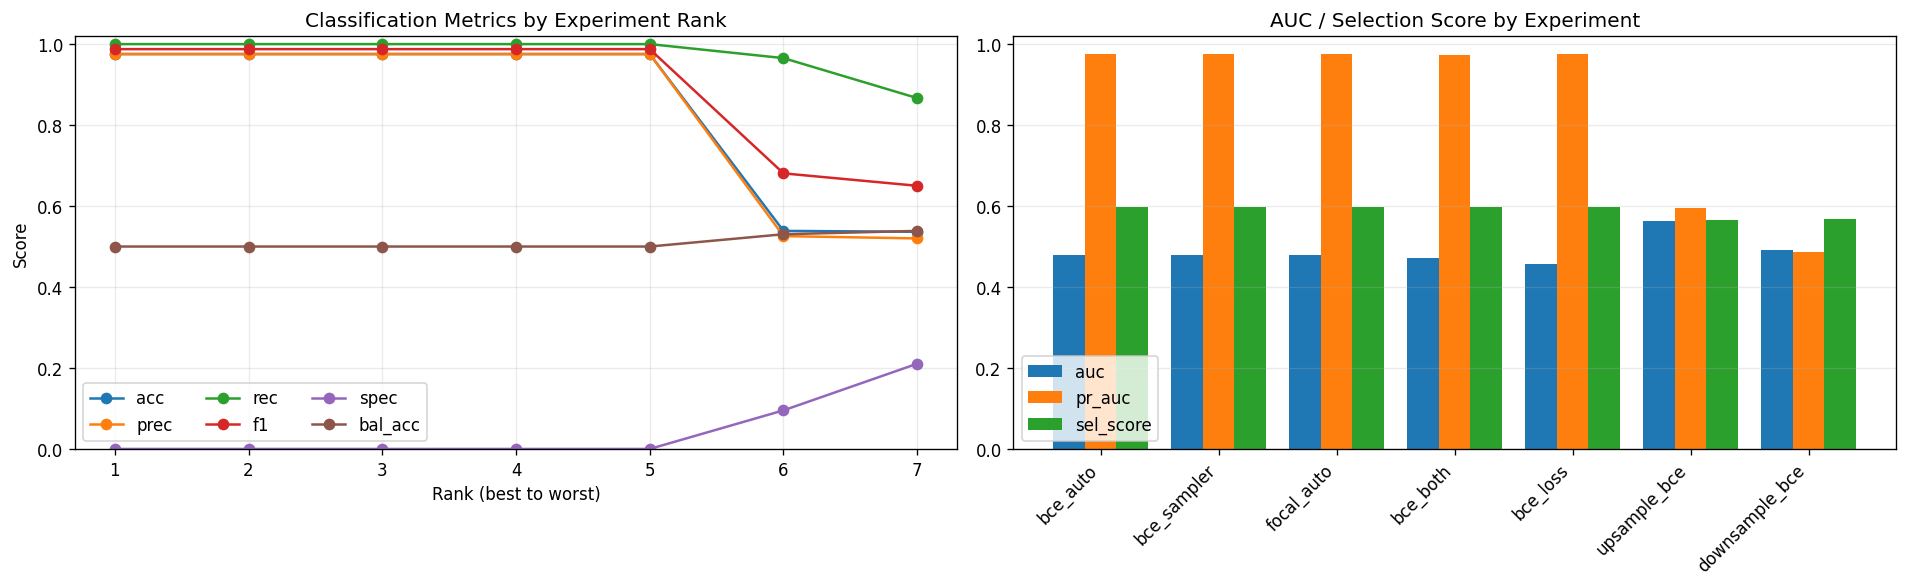

,name,strict_pass,targets_met,target_gap,acc,prec,rec,f1,spec,bal_acc,auc,sel_score,thr
0,bce_auto,False,True,0.000000,0.975410,0.975410,1.000000,0.987552,0.000000,0.500000,0.479249,0.597510,0.324055
1,bce_sampler,False,True,0.000000,0.975410,0.975410,1.000000,0.987552,0.000000,0.500000,0.479249,0.597510,0.324055
2,focal_auto,False,True,0.000000,0.975410,0.975410,1.000000,0.987552,0.000000,0.500000,0.479108,0.597510,0.340217
3,bce_both,False,True,0.000000,0.975410,0.975410,1.000000,0.987552,0.000000,0.500000,0.472713,0.597510,0.312364
4,bce_loss,False,True,0.000000,0.975410,0.975410,1.000000,0.987552,0.000000,0.500000,0.458055,0.597510,0.462606
5,upsample_bce,False,False,1.004932,0.538620,0.525718,0.965378,0.680730,0.095321,0.530350,0.563992,0.566715,0.489852
6,downsample_bce,False,False,1.056909,0.536424,0.520000,0.866667,0.650000,0.210526,0.538596,0.490877,0.567448,0.527677


In [15]:
# Plot experiment metrics from leaderboard CSV
import pandas as pd
import matplotlib.pyplot as plt

lb_path = BACKEND_ROOT / 'models' / 'nb_cls_leaderboard.csv'
if not lb_path.exists():
    raise FileNotFoundError(f'Leaderboard not found: {lb_path}. Run the sweep cell first.')

df = pd.read_csv(lb_path)
if 'error' in df.columns:
    df_ok = df[df['error'].isna()].copy()
else:
    df_ok = df.copy()

if df_ok.empty:
    raise RuntimeError('No successful experiments to plot. Check sweep errors first.')

# Keep a stable ranking for plotting.
sort_cols = [c for c in ['strict_pass', 'targets_met', 'target_gap', 'sel_score', 'auc'] if c in df_ok.columns]
if sort_cols:
    ascending = [False if c in {'strict_pass', 'targets_met', 'sel_score', 'auc'} else True for c in sort_cols]
    df_ok = df_ok.sort_values(sort_cols, ascending=ascending)

df_ok = df_ok.reset_index(drop=True)
df_ok['rank'] = df_ok.index + 1

metric_cols = [c for c in ['acc', 'prec', 'rec', 'f1', 'spec', 'bal_acc', 'auc', 'pr_auc', 'sel_score'] if c in df_ok.columns]
if not metric_cols:
    raise RuntimeError('No metric columns found in leaderboard.')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=120)

# 1) Line plot by rank
for m in [c for c in ['acc', 'prec', 'rec', 'f1', 'spec', 'bal_acc'] if c in metric_cols]:
    axes[0].plot(df_ok['rank'], df_ok[m], marker='o', label=m)
axes[0].set_title('Classification Metrics by Experiment Rank')
axes[0].set_xlabel('Rank (best to worst)')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.25)
axes[0].legend(loc='lower left', ncols=3)

# 2) Bar plot for auc/sel_score style metrics
bar_metrics = [c for c in ['auc', 'pr_auc', 'sel_score'] if c in metric_cols]
if bar_metrics:
    x = range(len(df_ok))
    width = 0.8 / len(bar_metrics)
    for i, m in enumerate(bar_metrics):
        axes[1].bar([v + i * width for v in x], df_ok[m], width=width, label=m)
    axes[1].set_xticks([v + width * (len(bar_metrics)-1) / 2 for v in x])
    axes[1].set_xticklabels(df_ok['name'], rotation=45, ha='right')
    axes[1].set_ylim(0, 1.02)
    axes[1].set_title('AUC / Selection Score by Experiment')
    axes[1].grid(axis='y', alpha=0.25)
    axes[1].legend(loc='lower left')
else:
    axes[1].axis('off')

plt.tight_layout()
plt.show()

# Quick text summary table
show_cols = [c for c in ['name', 'strict_pass', 'targets_met', 'target_gap', 'acc', 'prec', 'rec', 'f1', 'spec', 'bal_acc', 'auc', 'sel_score', 'thr'] if c in df_ok.columns]
display(df_ok[show_cols])


## 7) Scripted evidence + classification sweeps
Use the shell scripts added under `backend/scripts/` so every run is reproducible and auditable.


In [1]:
from pathlib import Path
import os, subprocess, json
import pandas as pd

if 'BACKEND_ROOT' not in globals() or not (Path(BACKEND_ROOT) / 'src').exists():
    _candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path('/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend'),
        Path('/content/CausalX-Project/backend'),
    ]
    BACKEND_ROOT = next((c for c in _candidates if (c / 'src').exists()), None)

if BACKEND_ROOT is None:
    raise RuntimeError('Cannot find backend root with src/ directory.')

ARCHIVE_SCRIPT = BACKEND_ROOT / 'scripts' / 'archive_cfn_evidence.sh'
RUNNER_SCRIPT = BACKEND_ROOT / 'scripts' / 'run_cfn_feature_upgrade.sh'
for p in [ARCHIVE_SCRIPT, RUNNER_SCRIPT]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required script: {p}')

def run_cmd(cmd, env=None, cwd=BACKEND_ROOT):
    cmd = [str(x) for x in cmd]
    print('\n$ ' + ' '.join(cmd))
    subprocess.run(cmd, cwd=str(cwd), env=env, check=True)

print('BACKEND_ROOT   =', BACKEND_ROOT)
print('ARCHIVE_SCRIPT =', ARCHIVE_SCRIPT)
print('RUNNER_SCRIPT  =', RUNNER_SCRIPT)


BACKEND_ROOT   = /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend
ARCHIVE_SCRIPT = /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/archive_cfn_evidence.sh
RUNNER_SCRIPT  = /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/run_cfn_feature_upgrade.sh


In [2]:
# 7.1 Snapshot current state before new sweeps
SNAPSHOT_PRE_TAG = 'pre_cls_sweep_notebook'
run_cmd([ARCHIVE_SCRIPT, SNAPSHOT_PRE_TAG])



$ /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/archive_cfn_evidence.sh pre_cls_sweep_notebook
Evidence snapshot created: /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/evidence/cfn_pre_cls_sweep_notebook
Manifest: /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/evidence/cfn_pre_cls_sweep_notebook/meta/sha256_manifest.txt


In [3]:
# 7.2 (Optional) Regenerate feature CSV, then rebuild mixed train/val/test splits
# Keep this OFF on Mac hosts where MediaPipe FaceMesh may fail to initialize (NSGL issue).
REBUILD_FEATURES = False

if REBUILD_FEATURES:
    proc_csv = BACKEND_ROOT / 'data/processed/causal_multimodal_dataset.csv'
    backup_csv = BACKEND_ROOT / 'data/processed/causal_multimodal_dataset_pre_rebuild_backup.csv'
    if proc_csv.exists():
        proc_csv.replace(backup_csv)
        print('Backed up:', backup_csv)

    env = os.environ.copy()
    env.setdefault('PYTHONPATH', '.')
    env.setdefault('MEDIAPIPE_DISABLE_GPU', '1')
    env.setdefault('CUDA_VISIBLE_DEVICES', '-1')
    env.setdefault('MPLCONFIGDIR', '/tmp/mpl')
    run_cmd(['.venv/bin/python', '-m', 'src.preprocessing.batch_feature_extractor'], env=env)

    if not proc_csv.exists() and backup_csv.exists():
        backup_csv.replace(proc_csv)
        raise RuntimeError('Feature rebuild produced no CSV; restored backup.')

env = os.environ.copy()
env.setdefault('PYTHONPATH', '.')
run_cmd([
    '.venv/bin/python', 'scripts/build_mixed_splits.py',
    '--processed-csv', 'data/processed/causal_multimodal_dataset.csv',
], env=env)



$ .venv/bin/python scripts/build_mixed_splits.py --processed-csv data/processed/causal_multimodal_dataset.csv
Split sizes (unique videos):
  train: 15248 val: 3268 test: 3268
Processed rows:
  train: 15248 val: 3268 test: 3268
Manifest rows:
  val: 3268 test: 3268
Missing paths dropped:
  val: 0 test: 0
Outputs:
  data/processed/causal_multimodal_dataset_mixed_train.csv
  data/processed/causal_multimodal_dataset_mixed_val.csv
  data/processed/causal_multimodal_dataset_mixed_test.csv
  eval_manifest_mixed_val.tsv
  eval_manifest_mixed_test.tsv


In [1]:
# 7.3 Run scripted classification-focused experiments (ablation v2)
from pathlib import Path
import os, subprocess

# Self-heal if setup cell was not executed.
if 'BACKEND_ROOT' not in globals() or not Path(BACKEND_ROOT).exists() or not (Path(BACKEND_ROOT) / 'src').exists():
    _candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path('/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend'),
        Path('/content/CausalX-Project/backend'),
    ]
    BACKEND_ROOT = next((c for c in _candidates if (c / 'src').exists()), None)

if BACKEND_ROOT is None:
    raise RuntimeError('Cannot find backend root with src/ directory.')

if 'RUNNER_SCRIPT' not in globals() or not Path(RUNNER_SCRIPT).exists():
    RUNNER_SCRIPT = BACKEND_ROOT / 'scripts' / 'run_cfn_feature_upgrade.sh'

if not Path(RUNNER_SCRIPT).exists():
    raise FileNotFoundError(f'Missing run script: {RUNNER_SCRIPT}')

if 'run_cmd' not in globals():
    def run_cmd(cmd, env=None, cwd=BACKEND_ROOT):
        cmd = [str(x) for x in cmd]
        print('\n$ ' + ' '.join(cmd))
        subprocess.run(cmd, cwd=str(cwd), env=env, check=True)


def run_scripted_experiment(run_tag: str, **env_overrides):
    env = os.environ.copy()
    for k, v in env_overrides.items():
        env[k] = str(v)
    env['RUN_TAG'] = run_tag
    run_cmd([RUNNER_SCRIPT], env=env)

COMMON = dict(
    TRAIN_SOURCE='all',
    CLASS_BALANCE_MODE='none',
    WEIGHT_APPLICATION='auto',
    SELECTION_THRESHOLD_MODE='target',
    SELECTION_METRIC='hybrid_robust',
    TARGET_PRECISION='0.70',
    TARGET_RECALL='0.70',
    TARGET_PRIORITY='balanced_acc',
    EPOCHS='50',
    PATIENCE='10',
    MIN_DOMAIN_SPEC='0.05',
    MIN_DOMAIN_REC='0.20',
)

# A) Baseline features (control)
run_scripted_experiment(
    'featup_ablate_baseline_auto_v2_nb',
    FEATURE_PROFILE='baseline',
    HARD_NEG_WEIGHT='1.0',
    **COMMON,
)

# B) Extended features with original hard-negative emphasis
run_scripted_experiment(
    'featup_ablate_extended_auto_v2_nb',
    FEATURE_PROFILE='extended',
    HARD_NEG_WEIGHT='6.0',
    **COMMON,
)

# C) Extended features with reduced hard-negative emphasis
run_scripted_experiment(
    'featup_ablate_extended_auto_hn1_v2_nb',
    FEATURE_PROFILE='extended',
    HARD_NEG_WEIGHT='1.0',
    **COMMON,
)




$ /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/run_cfn_feature_upgrade.sh
Run tag: featup_ablate_baseline_auto_v2_nb
Model dir: models/featup_ablate_baseline_auto_v2_nb
Log file: models/experiment_logs/train_featup_ablate_baseline_auto_v2_nb.log
Data: data/processed/causal_multimodal_dataset_mixed_train.csv
Feature profile: baseline
Target metrics for threshold calibration/reporting: {'prec': 0.7, 'rec': 0.7}
Using seed: 42
Loaded 15248 rows from data/processed/causal_multimodal_dataset_mixed_train.csv; using 15248 rows after --train-source=all filter.
Feature profile=baseline: av_dim=5 phys_dim=2
Label prevalence: pos=0.9753, neg=0.0247
Using group+domain+label stratified split by video_id across 4 groups.
Group split on 'video_id': train_groups=12198 val_groups=3050
Weight application (auto) resolved to: sampler.
Applied group balancing across 4 dataset-label groups.
Applied hard-negative weight to 21 training rows.
Using WeightedRandomSampler for train batch

/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/run_cfn_feature_upgrade.sh: line 109: rg: command not found
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/run_cfn_feature_upgrade.sh: line 110: rg: command not found


Run complete.
Artifacts:
  models/featup_ablate_baseline_auto_v2_nb/cfn_emb.pth
  models/featup_ablate_baseline_auto_v2_nb/cfn_scaler.pkl
  models/featup_ablate_baseline_auto_v2_nb/cfn_threshold_report.json
Tracking CSV: models/experiment_logs/feature_upgrade_runs.csv

$ /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/run_cfn_feature_upgrade.sh
Run tag: featup_ablate_extended_auto_v2_nb
Model dir: models/featup_ablate_extended_auto_v2_nb
Log file: models/experiment_logs/train_featup_ablate_extended_auto_v2_nb.log
Data: data/processed/causal_multimodal_dataset_mixed_train.csv
Feature profile: extended
Target metrics for threshold calibration/reporting: {'prec': 0.7, 'rec': 0.7}
Using seed: 42
Loaded 15248 rows from data/processed/causal_multimodal_dataset_mixed_train.csv; using 15248 rows after --train-source=all filter.
Feature profile=extended: av_dim=22 phys_dim=12
Label prevalence: pos=0.9753, neg=0.0247
Using group+domain+label stratified split by video_id acro

/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/run_cfn_feature_upgrade.sh: line 109: rg: command not found
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/run_cfn_feature_upgrade.sh: line 110: rg: command not found


Run complete.
Artifacts:
  models/featup_ablate_extended_auto_v2_nb/cfn_emb.pth
  models/featup_ablate_extended_auto_v2_nb/cfn_scaler.pkl
  models/featup_ablate_extended_auto_v2_nb/cfn_threshold_report.json
Tracking CSV: models/experiment_logs/feature_upgrade_runs.csv

$ /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/run_cfn_feature_upgrade.sh
Run tag: featup_ablate_extended_auto_hn1_v2_nb
Model dir: models/featup_ablate_extended_auto_hn1_v2_nb
Log file: models/experiment_logs/train_featup_ablate_extended_auto_hn1_v2_nb.log
Data: data/processed/causal_multimodal_dataset_mixed_train.csv
Feature profile: extended
Target metrics for threshold calibration/reporting: {'prec': 0.7, 'rec': 0.7}
Using seed: 42
Loaded 15248 rows from data/processed/causal_multimodal_dataset_mixed_train.csv; using 15248 rows after --train-source=all filter.
Feature profile=extended: av_dim=22 phys_dim=12
Label prevalence: pos=0.9753, neg=0.0247
Using group+domain+label stratified split by v

/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/run_cfn_feature_upgrade.sh: line 109: rg: command not found
/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/scripts/run_cfn_feature_upgrade.sh: line 110: rg: command not found


In [2]:
# 7.4 Summarize threshold reports for selected runs
from pathlib import Path
import json
import pandas as pd

if 'BACKEND_ROOT' not in globals() or not Path(BACKEND_ROOT).exists() or not (Path(BACKEND_ROOT) / 'src').exists():
    _candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path('/Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend'),
        Path('/content/CausalX-Project/backend'),
    ]
    BACKEND_ROOT = next((c for c in _candidates if (c / 'src').exists()), None)

if BACKEND_ROOT is None:
    raise RuntimeError('Cannot find backend root with src/ directory.')

RUN_TAGS = [
    'featup_target_v1_20260308',
    'featup_ablate_baseline_auto_v2_nb',
    'featup_ablate_extended_auto_v2_nb',
    'featup_ablate_extended_auto_hn1_v2_nb',
]

rows = []
for tag in RUN_TAGS:
    rp = BACKEND_ROOT / 'models' / tag / 'cfn_threshold_report.json'
    if not rp.exists():
        rows.append({'run_tag': tag, 'error': f'missing report: {rp}'})
        continue

    rep = json.loads(rp.read_text())
    chosen = rep.get('chosen_epoch_report', {})
    overall = chosen.get('overall_at_selection_threshold', {})
    rows.append({
        'run_tag': tag,
        'checkpoint_meets_constraints': rep.get('best_checkpoint_met_constraints'),
        'targets_met': chosen.get('targets_met'),
        'target_gap': chosen.get('target_shortfall'),
        'auc': chosen.get('val_auc'),
        'pr_auc': chosen.get('pr_auc'),
        'sel_score': chosen.get('selection_score'),
        'acc': overall.get('acc'),
        'prec': overall.get('prec'),
        'rec': overall.get('rec'),
        'spec': overall.get('spec'),
        'bal_acc': overall.get('bal_acc'),
        'f1': overall.get('f1'),
        'worst_spec': chosen.get('worst_spec'),
        'worst_rec': chosen.get('worst_rec'),
        'report_path': str(rp),
    })

summary = pd.DataFrame(rows)
if 'error' not in summary.columns:
    summary = summary.sort_values(
        by=['checkpoint_meets_constraints', 'targets_met', 'target_gap', 'sel_score', 'auc', 'bal_acc', 'f1'],
        ascending=[False, False, True, False, False, False, False],
    )
display(summary)

summary_out = BACKEND_ROOT / 'models' / 'experiment_logs' / 'nb_scripted_target_summary.csv'
summary.to_csv(summary_out, index=False)
print('Saved summary to', summary_out)



,run_tag,checkpoint_meets_constraints,targets_met,target_gap,auc,pr_auc,sel_score,acc,prec,rec,spec,bal_acc,f1,worst_spec,worst_rec,report_path
3,featup_ablate_extended_auto_hn1_v2_nb,True,True,0.000000,0.690765,0.988516,0.689820,0.741311,0.986643,0.744874,0.600000,0.672437,0.848880,0.600000,0.689655,/Users/venturit/Documents/GitHub/FYP/CausalX-P...
1,featup_ablate_baseline_auto_v2_nb,True,True,0.000000,0.537080,0.977494,0.628504,0.938033,0.976728,0.959328,0.093333,0.526331,0.967950,0.071429,0.931034,/Users/venturit/Documents/GitHub/FYP/CausalX-P...
2,featup_ablate_extended_auto_v2_nb,True,True,0.000000,0.464408,0.974309,0.604272,0.943934,0.976223,0.966050,0.066667,0.516359,0.971110,0.057143,0.827586,/Users/venturit/Documents/GitHub/FYP/CausalX-P...
0,featup_target_v1_20260308,True,False,0.212264,0.584912,0.596462,0.592099,0.556291,0.537736,0.760000,0.355263,0.557632,0.629834,0.347826,0.756757,/Users/venturit/Documents/GitHub/FYP/CausalX-P...


Saved summary to /Users/venturit/Documents/GitHub/FYP/CausalX-Project/backend/models/experiment_logs/nb_scripted_target_summary.csv
